<a href="https://colab.research.google.com/github/ofonime41/Titanic-Data-Exploration/blob/main/Titanic_Dataset_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Titanic Dataset Exploratory data analysis**


In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
file_path = '/content/drive/MyDrive/DEEPTECH COURSE RESOURCES/MENTORSHIP PHASE PROJECT/Titanic_Dataset.csv'
data = pd.read_csv(file_path)
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [50]:
display(data.head())
print('\n')
print('\n')
display(data.tail())

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1308,1309,28.0,22.3583,0,1,0,0,0,0,0,...,0,0,0,3,0,0,0.0,0,0,0


# DATA CLEANING
We have several columns named 'zero' that contains 0 value which is not useful in this analysis and need to be removed

In [51]:
drop_columns = [col for col in data.columns if 'zero' in col]

data = data.drop(columns=drop_columns)


print(data.columns)

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass',
       'Embarked', '2urvived'],
      dtype='object')


In [52]:
# Rename the column '2urvived' to Survived

data.rename(columns={'2urvived': 'Survived'})
data = data.rename(columns={'2urvived': 'Survived'})
data.head()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


In [53]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   Survived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


In [54]:
# EMBARKED COLUMN HAS 307 ROWS INSTEAD OF 1309, WE FIX THAT BY REPLACING THE MISSING VALUE WITH THE MOST COMMON VAlue
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1309 non-null   float64
 8   Survived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


## ANALYSISING THE DATASET

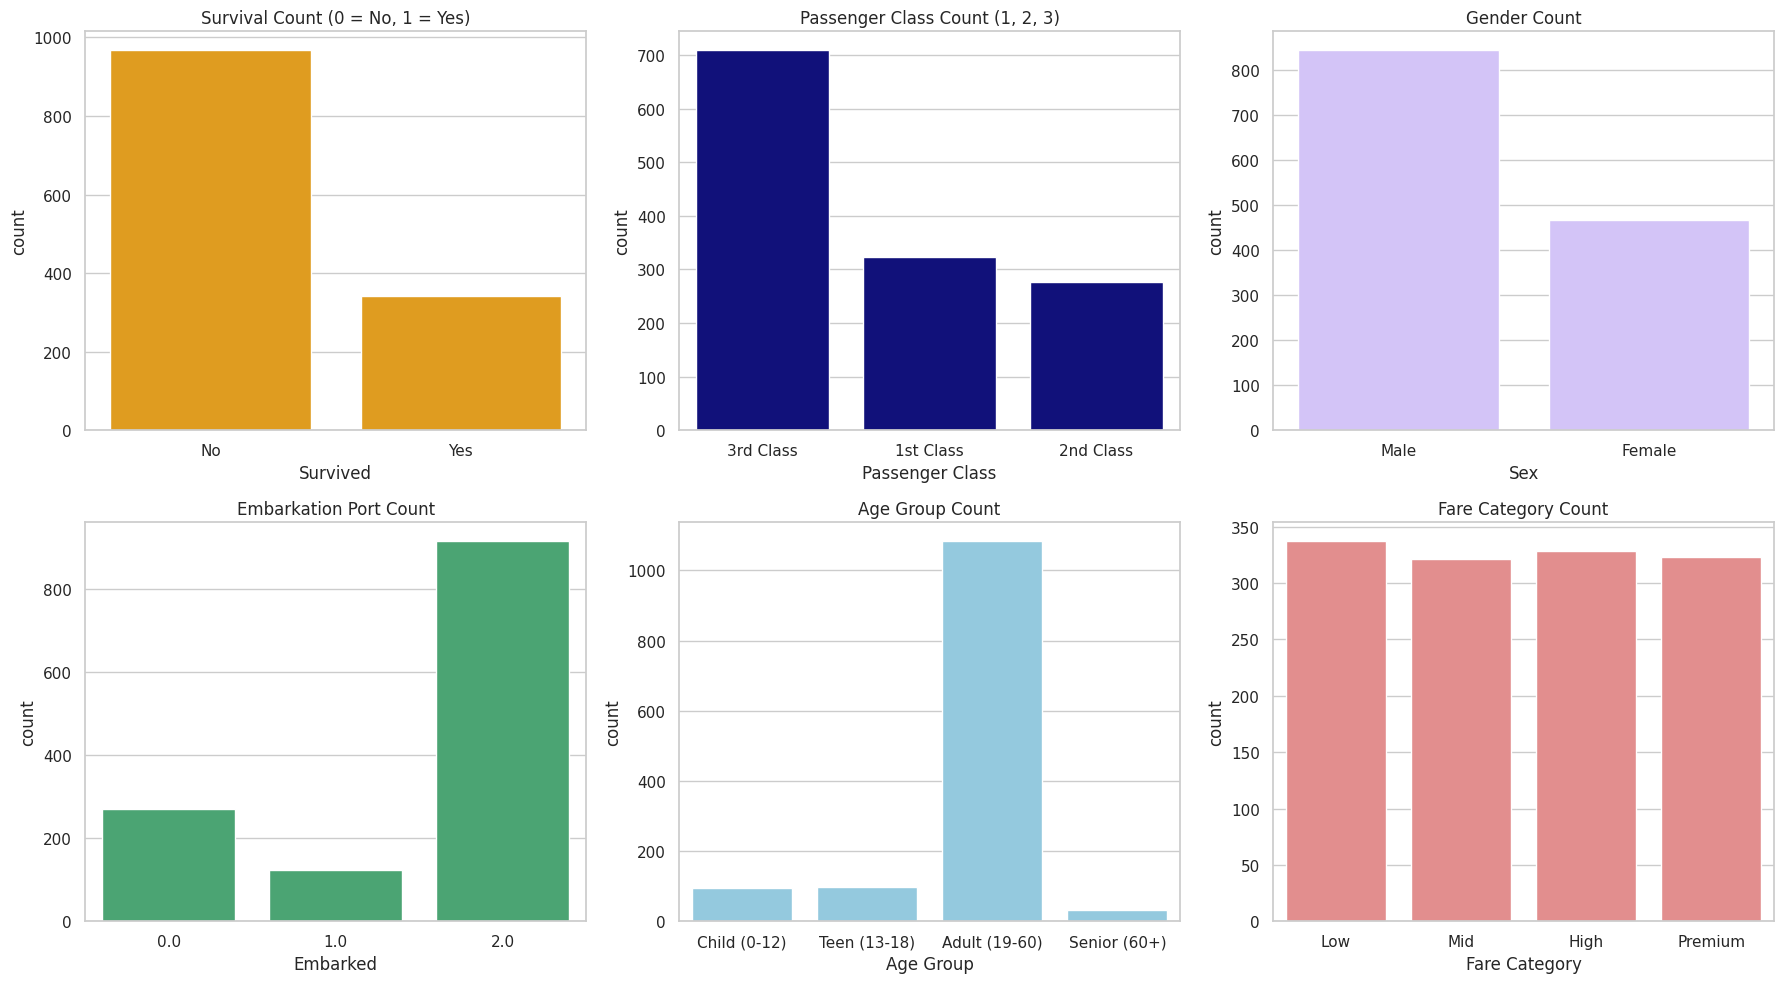

In [55]:
# 1. Group the Age and Fare columns into categories
# Binning Age into exact ranges
age_limits = [0, 12, 18, 60, 120]
age_labels = ['Child (0-12)', 'Teen (13-18)', 'Adult (19-60)', 'Senior (60+)']
data['Age Group'] = pd.cut(data['Age'], bins=age_limits, labels=age_labels)

# Binning Fare into 4 groups with an equal number of passengers in each
fare_labels = ['Low', 'Mid', 'High', 'Premium']
data['Fare Category'] = pd.qcut(data['Fare'], q=4, labels=fare_labels)

# 2. Create a 2x3 grid for 6 charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Creating Labels
sex_labels = {0: 'Male', 1: 'Female'}
survive_labels = {0: 'No', 1: 'Yes'}
class_labels = {1: '1st Class', 2: '2nd Class', 3: '3rd Class'}

# Row 1 Plots
sns.countplot(x=data['Survived'].map(survive_labels), ax=axes[0, 0], color='orange')
axes[0, 0].set_title('Survival Count (0 = No, 1 = Yes)')
axes[0, 0].set_xlabel('Survived')

sns.countplot(x=data['Pclass'].map(class_labels), ax=axes[0, 1], color='darkblue')
axes[0, 1].set_title('Passenger Class Count (1, 2, 3)')
axes[0, 1].set_xlabel('Passenger Class')

sns.countplot(x=data['Sex'].map(sex_labels), ax=axes[0, 2], color='#d0bbff')
axes[0, 2].set_title('Gender Count')
axes[0, 2].set_xlabel('Sex')

# Row 2 Plots
sns.countplot(data=data, x='Embarked', ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Embarkation Port Count')

sns.countplot(data=data, x='Age Group', ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title('Age Group Count')

sns.countplot(data=data, x='Fare Category', ax=axes[1, 2], color='lightcoral')
axes[1, 2].set_title('Fare Category Count')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

### Reviewing  how passenger class, gender, and embarkation port affected survival rates

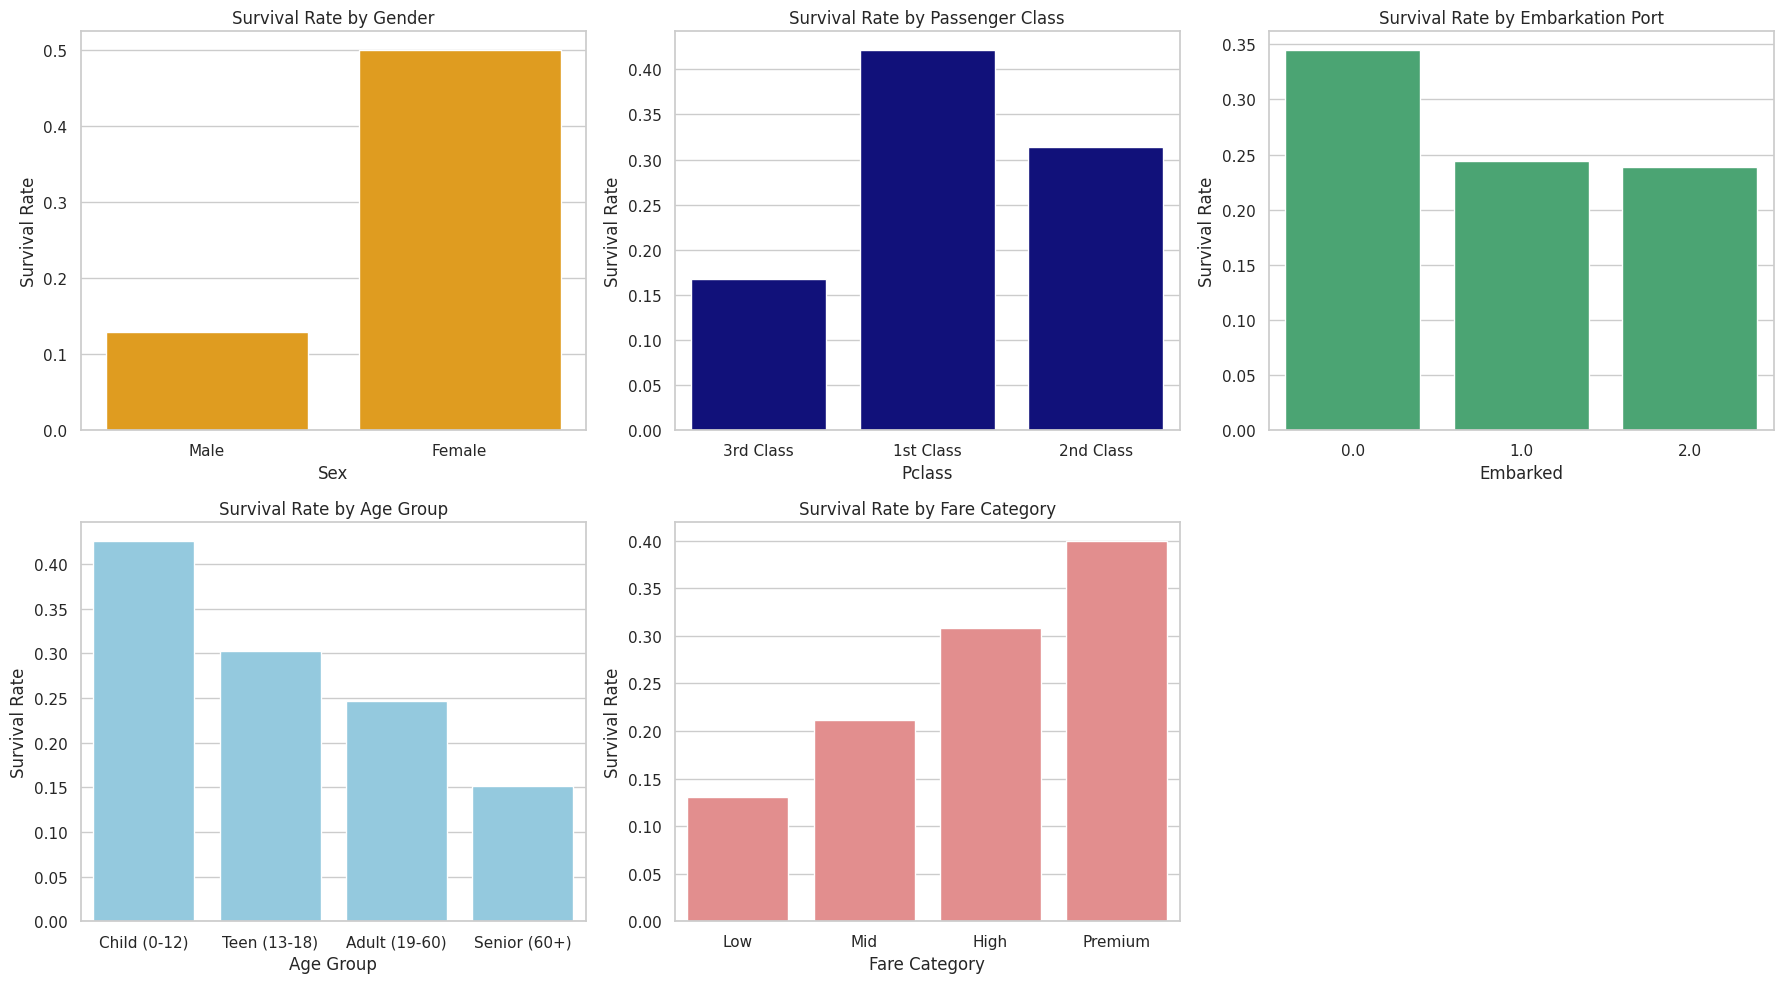

In [56]:
# Set the visual theme
sns.set_theme(style="whitegrid")

# Create a 2x3 grid to fit 5 charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Labels for mapping
sex_labels = {0: 'Male', 1: 'Female'}
class_labels = {1: '1st Class', 2: '2nd Class', 3: '3rd Class'}

# Row 1: Sex, Pclass, Embarked
sns.barplot(x=data['Sex'].map(sex_labels), y=data['Survived'], ax=axes[0, 0], errorbar=None, color='orange')
axes[0, 0].set_title('Survival Rate by Gender')
axes[0, 0].set_ylabel('Survival Rate')

sns.barplot(x=data['Pclass'].map(class_labels), y=data['Survived'], ax=axes[0, 1], errorbar=None, color='darkblue')
axes[0, 1].set_title('Survival Rate by Passenger Class')
axes[0, 1].set_ylabel('Survival Rate')

sns.barplot(data=data, x='Embarked', y='Survived', ax=axes[0, 2], errorbar=None, color='mediumseagreen')
axes[0, 2].set_title('Survival Rate by Embarkation Port')
axes[0, 2].set_ylabel('Survival Rate')

# Row 2: Age Group, Fare Category
sns.barplot(data=data, x='Age Group', y='Survived', ax=axes[1, 0], errorbar=None, color='skyblue')
axes[1, 0].set_title('Survival Rate by Age Group')
axes[1, 0].set_ylabel('Survival Rate')

sns.barplot(data=data, x='Fare Category', y='Survived', ax=axes[1, 1], errorbar=None, color='lightcoral')
axes[1, 1].set_title('Survival Rate by Fare Category')
axes[1, 1].set_ylabel('Survival Rate')

# Hide the empty 6th subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Reviewing the Results

##A critical question arises from the data: why did women and children, typically the most vulnerable groups in such emergencies, have the highest survival rates?

###The answer lies in the historical context of the Titanic. During the evacuation, Captain Edward Smith issued the official order to load women and children into the lifeboats first. The ship's officers enforced this protocol strictly. In many cases, officers actively prevented adult men from boarding the lifeboats—even when seats were available—to reserve them entirely for these vulnerable populations.

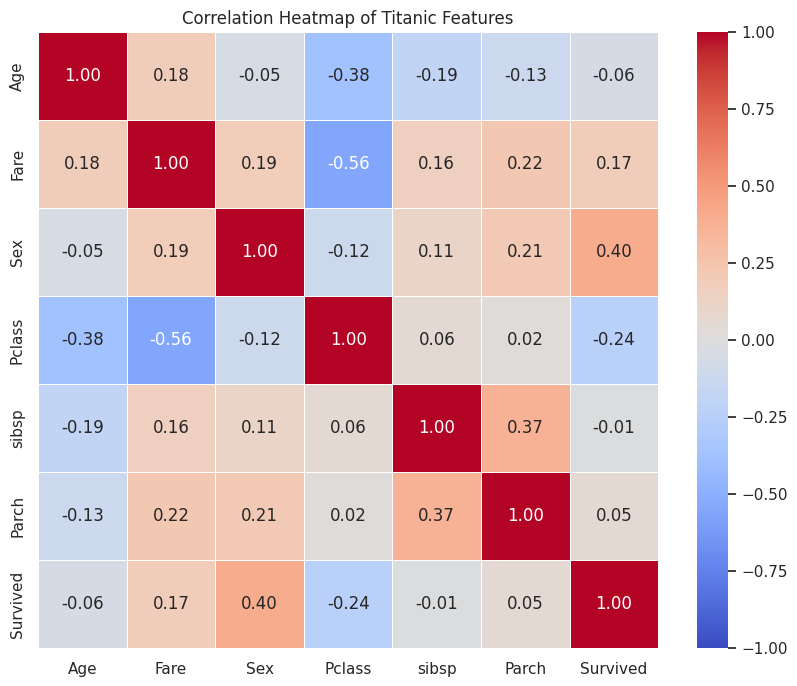

In [57]:
numeric_columns = ['Age', 'Fare', 'Sex', 'Pclass', 'sibsp', 'Parch', 'Survived']
numeric_data = data[numeric_columns]

# 2. Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

# 3. Set up the plotting area
plt.figure(figsize=(10, 8))

# 4. Draw the heatmap
# annot=True puts the numbers inside the boxes
# cmap='coolwarm' uses red for positive correlation and blue for negative
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Titanic Features')
plt.show()

##Analysising the heatmap it reflects:

### There is a strong correlation between the sex and the survival rate
